# Import Libraries

In [2]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Loading the Data

In [3]:
train = pd.read_csv('data/train.csv', sep='|')
items = pd.read_csv('data/items.csv', sep='|')

df = train.merge(items, 
                   on='pid', 
                   how='left',
                   validate="m:1")


# Initial Data Analysis

In [47]:
df.head()

,lineID,day,pid,adFlag,availability,competitorPrice,click,basket,order,price,...,manufacturer,group,content,unit,pharmForm,genericProduct,salesIndex,category,campaignIndex,rrp
0,1,1,6570,0,2,14.60,1,0,0,16.89,...,255,2FOI,50,ML,TRO,0,40,193.0,NaN,18.25
1,2,1,14922,1,1,8.57,0,1,0,8.75,...,18,1COJ0FIK,50,ST,TAB,1,40,66.0,C,18.81
2,3,1,16382,0,1,14.77,0,1,0,16.06,...,41,22OI7,2X50,ML,STI,0,53,40.0,NaN,18.48
3,4,1,1145,1,1,6.59,0,0,1,6.55,...,52,18OZ00IS,60,G,GEL,0,40,25.0,NaN,9.31
4,5,1,3394,0,1,4.39,0,0,1,4.14,...,90,20OI0,25X2,ST,KOM,0,53,14.0,NaN,8.13


In [48]:
df.isnull().sum()

lineID                   0
day                      0
pid                      0
adFlag                   0
availability             0
competitorPrice     100687
click                    0
basket                   0
order                    0
price                    0
revenue                  0
manufacturer             0
group                    0
content                  0
unit                     0
pharmForm           194124
genericProduct           0
salesIndex               0
category             87394
campaignIndex      2287968
rrp                      0
dtype: int64

In [49]:
df[df.isnull().any(axis=1)]

,lineID,day,pid,adFlag,availability,competitorPrice,click,basket,order,price,...,manufacturer,group,content,unit,pharmForm,genericProduct,salesIndex,category,campaignIndex,rrp
0,1,1,6570,0,2,14.60,1,0,0,16.89,...,255,2FOI,50,ML,TRO,0,40,193.0,NaN,18.25
2,3,1,16382,0,1,14.77,0,1,0,16.06,...,41,22OI7,2X50,ML,STI,0,53,40.0,NaN,18.48
3,4,1,1145,1,1,6.59,0,0,1,6.55,...,52,18OZ00IS,60,G,GEL,0,40,25.0,NaN,9.31
4,5,1,3394,0,1,4.39,0,0,1,4.14,...,90,20OI0,25X2,ST,KOM,0,53,14.0,NaN,8.13
5,6,1,3661,0,1,13.66,0,0,1,10.03,...,90,13OX06,1000,ML,LOE,0,52,127.0,NaN,21.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2755996,2755997,92,17611,0,1,2.52,0,0,1,3.12,...,52,21OK3,20,ST,LUT,0,53,57.0,NaN,3.29
2755997,2755998,92,21407,1,1,12.09,0,0,1,13.14,...,200,1DOIF0ZO,10,ML,ATR,0,53,137.0,NaN,17.55
2755998,2755999,92,15767,0,1,22.41,1,0,0,18.64,...,917,22OIE,15,ML,LOT,0,53,15.0,NaN,24.75
2755999,2756000,92,2087,0,1,36.87,1,0,0,43.18,...,18,14OH2F,200,ST,KAP,0,40,100.0,NaN,46.09


In [50]:
df.nunique()

lineID             2756003
day                     92
pid                  21928
adFlag                   2
availability             4
competitorPrice       4992
click                    2
basket                   2
order                    2
price                 7475
revenue               7520
manufacturer          1065
group                  533
content                548
unit                     8
pharmForm              278
genericProduct           2
salesIndex               4
category               409
campaignIndex            3
rrp                   3282
dtype: int64

In [ ]:
df['order'].value_counts()

order
0    2050913
1     705090
Name: count, dtype: int64

In [56]:
df.describe().apply(lambda s: s.apply('{0:.2f}'.format))

,lineID,day,pid,adFlag,availability,competitorPrice,click,basket,order,price,revenue,manufacturer,genericProduct,salesIndex,category,rrp
count,2756003.00,2756003.00,2756003.00,2756003.00,2756003.00,2655316.00,2756003.00,2756003.00,2756003.00,2756003.00,2756003.00,2756003.00,2756003.00,2756003.00,2668609.00,2756003.00
mean,1378002.00,49.92,10447.90,0.32,1.11,12.77,0.57,0.17,0.26,13.85,3.75,174.45,0.11,46.24,115.43,18.31
std,795589.68,25.29,6456.01,0.47,0.39,12.75,0.49,0.38,0.44,13.62,10.24,187.31,0.31,6.42,93.69,18.66
min,1.00,1.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.02,0.00,1.00,0.00,40.00,1.00,0.07
25%,689001.50,31.00,4313.00,0.00,1.00,5.48,0.00,0.00,0.00,6.00,0.00,56.00,0.00,40.00,46.00,7.98
50%,1378002.00,50.00,10077.00,0.00,1.00,8.99,1.00,0.00,0.00,9.85,0.00,104.00,0.00,40.00,92.00,13.17
75%,2067002.50,71.00,16144.00,1.00,1.00,15.06,1.00,0.00,1.00,16.45,1.93,220.00,0.00,53.00,152.00,21.95
max,2756003.00,92.00,22035.00,1.00,4.00,264.59,1.00,1.00,1.00,378.84,887.70,1067.00,1.00,53.00,409.00,404.97


In [65]:
df.corr(numeric_only=True)

,lineID,day,pid,adFlag,availability,competitorPrice,click,basket,order,price,revenue,manufacturer,genericProduct,salesIndex,category,rrp
lineID,1.000000,0.997790,0.001692,-0.023196,0.017553,0.022622,0.108867,-0.059316,-0.072321,0.021408,-0.038033,0.018571,-0.021934,0.010778,-0.002856,0.018391
day,0.997790,1.000000,0.002313,-0.024418,0.019050,0.023958,0.116116,-0.063016,-0.077351,0.022835,-0.040944,0.019701,-0.023436,0.011661,-0.002431,0.019674
pid,0.001692,0.002313,1.000000,-0.123018,0.006680,0.096790,0.086887,-0.072414,-0.036142,0.109019,0.019133,0.149825,-0.159052,0.223889,0.150136,0.073575
adFlag,-0.023196,-0.024418,-0.123018,1.000000,-0.173211,0.009946,-0.179366,0.115209,0.104110,0.023665,0.072515,-0.125159,0.123904,-0.298401,0.046119,0.061104
availability,0.017553,0.019050,0.006680,-0.173211,1.000000,0.036423,0.119770,-0.054229,-0.089054,0.051254,-0.048652,0.091998,-0.057354,0.056178,-0.000685,0.008324
competitorPrice,0.022622,0.023958,0.096790,0.009946,0.036423,1.000000,0.105058,-0.049298,-0.076286,0.954357,0.220593,0.106564,-0.195641,0.156753,0.074693,0.967402
click,0.108867,0.116116,0.086887,-0.179366,0.119770,0.105058,1.000000,-0.525385,-0.681058,0.109766,-0.425515,0.090304,-0.120605,0.135857,0.022861,0.081443
basket,-0.059316,-0.063016,-0.072414,0.115209,-0.054229,-0.049298,-0.525385,1.000000,-0.265211,-0.050823,-0.165700,-0.042592,0.049100,-0.091190,-0.003729,-0.035971
order,-0.072321,-0.077351,-0.036142,0.104110,-0.089054,-0.076286,-0.681058,-0.265211,1.000000,-0.080649,0.624785,-0.065678,0.094414,-0.075476,-0.022645,-0.061336
price,0.021408,0.022835,0.109019,0.023665,0.051254,0.954357,0.109766,-0.050823,-0.080649,1.000000,0.216488,0.120384,-0.190935,0.120024,0.080044,0.935825


In [66]:
df.corr(numeric_only=True)['order'].sort_values(ascending=False)

order              1.000000
revenue            0.624785
adFlag             0.104110
genericProduct     0.094414
category          -0.022645
pid               -0.036142
rrp               -0.061336
manufacturer      -0.065678
lineID            -0.072321
salesIndex        -0.075476
competitorPrice   -0.076286
day               -0.077351
price             -0.080649
availability      -0.089054
basket            -0.265211
click             -0.681058
Name: order, dtype: float64

# Exploratory Data Analysis

## Order

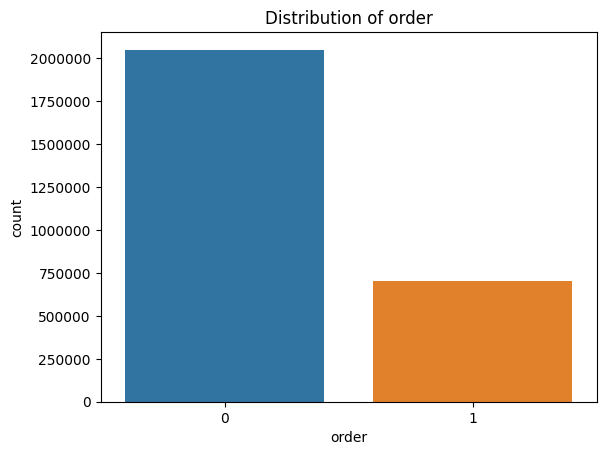

In [ ]:
plot = sns.countplot(x="order", hue="order", data=df)
if plot.legend_ is not None:
    plot.legend_.remove()

plot.get_yaxis().get_major_formatter().set_scientific(False)

plt.title("Distribution of Order Flag")
plt.show()

## Day

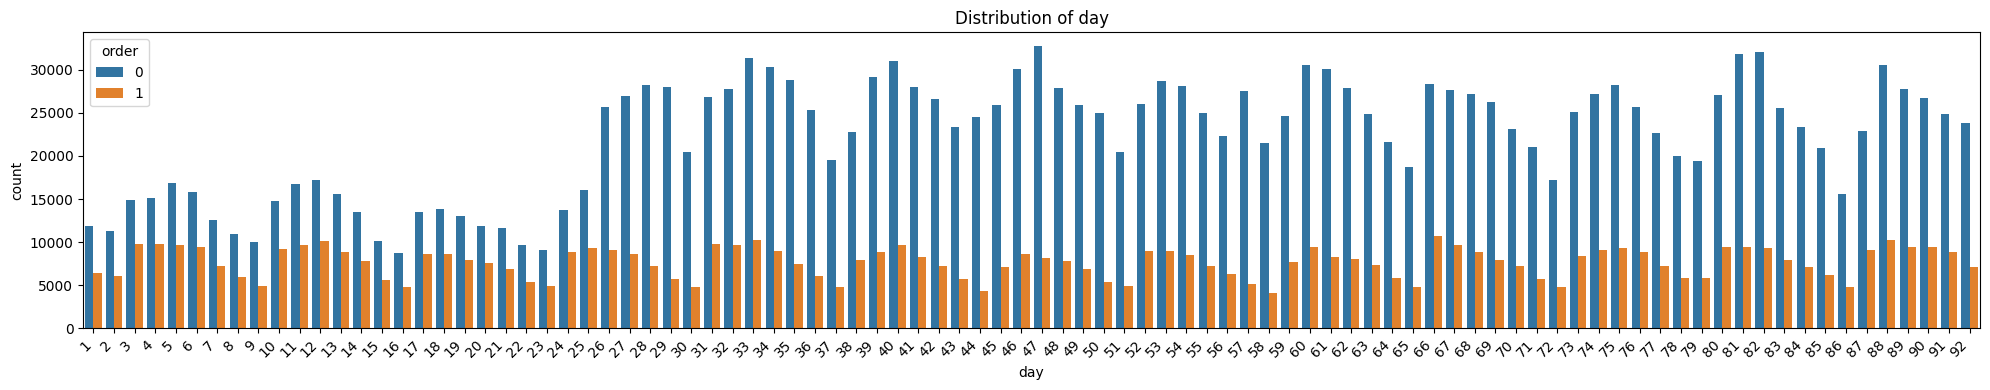

In [ ]:
plt.figure(figsize=(20, 4))
plot = sns.countplot(data=df, x="day", hue="order")

plot.set_title("Distribution of Day")
plot.tick_params(axis="x", labelrotation=45)
for label in plot.get_xticklabels():
    label.set_ha("right")

plt.tight_layout()
plt.show()

## Pid

In [ ]:
plt.figure(figsize=(50, 4))
plot = sns.countplot(x="pid", hue="order", data=df)

plt.title("Distribution of Products")
plt.show()

## Ad Flag

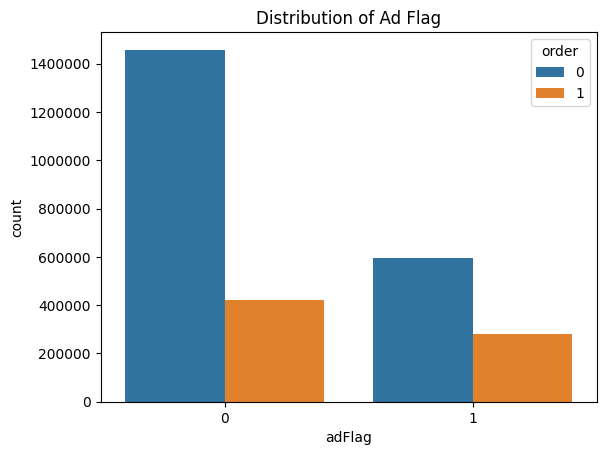

In [19]:
plot = sns.countplot(x="adFlag", hue="order", data=df)
plot.get_yaxis().get_major_formatter().set_scientific(False)

plt.title("Distribution of Ad Flag")
plt.show()

## Availability

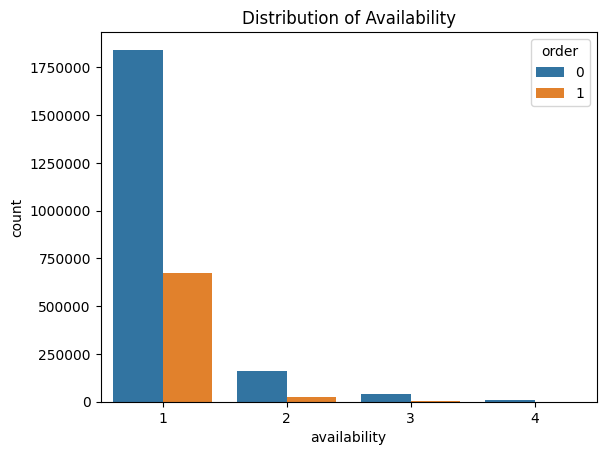

In [20]:
plot = sns.countplot(x="availability", hue="order", data=df)
plot.get_yaxis().get_major_formatter().set_scientific(False)

plt.title("Distribution of Availability")
plt.show()

## Competitor Price

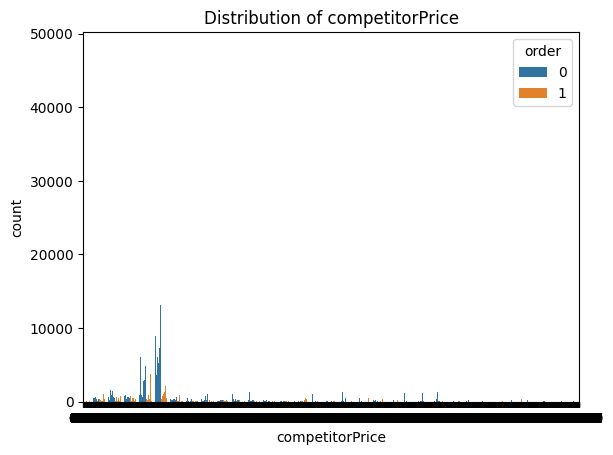

In [ ]:
plot = sns.countplot(x="competitorPrice", hue="order", data=df)
plot.get_yaxis().get_major_formatter().set_scientific(False)

plt.title("Distribution of Competitor Price")
plt.show()

## Click

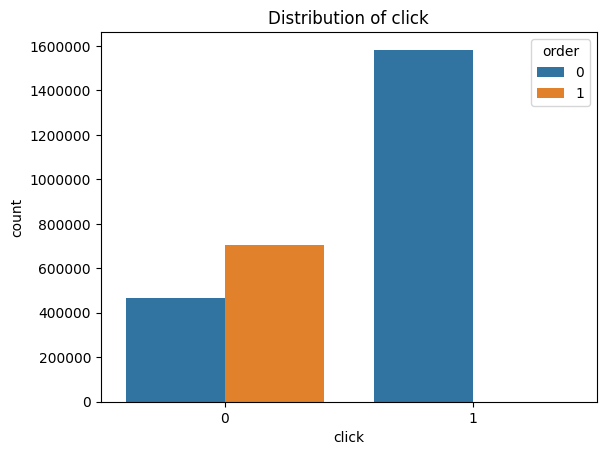

In [ ]:
plot = sns.countplot(x="click", hue="order", data=df)
plot.get_yaxis().get_major_formatter().set_scientific(False)

plt.title("Distribution of Click Flag")
plt.show()

## Basket

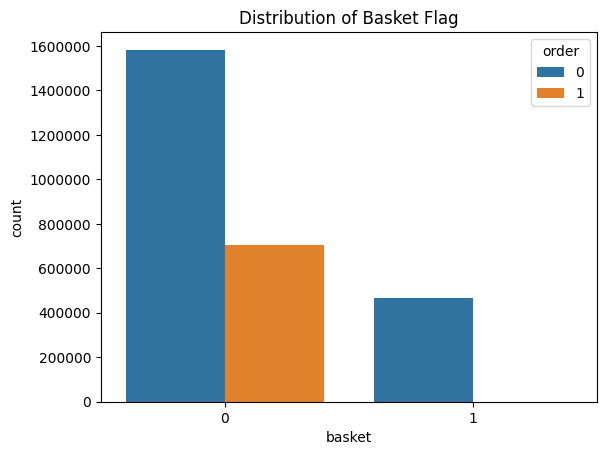

In [22]:
plot = sns.countplot(x="basket", hue="order", data=df)
plot.get_yaxis().get_major_formatter().set_scientific(False)

plt.title("Distribution of Basket Flag")
plt.show()

## Price

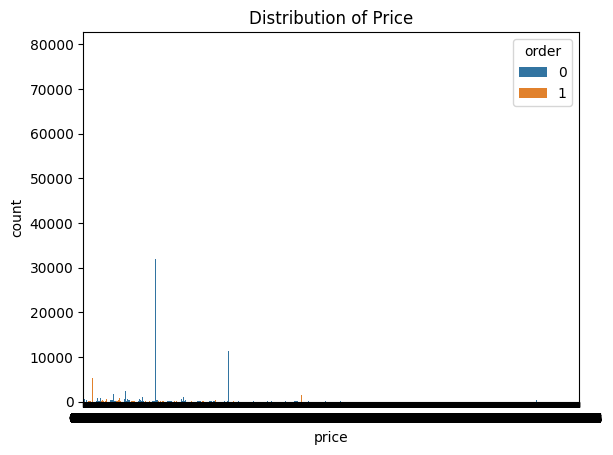

In [21]:
plot = sns.countplot(x="price", hue="order", data=df)

plt.title("Distribution of Price")
plt.show()

## Revenue

In [ ]:
plot = sns.countplot(x="revenue", hue="order", data=df)
plot.get_yaxis().get_major_formatter().set_scientific(False)

plt.title("Distribution of Revenue")
plt.show()

## Manufacturer

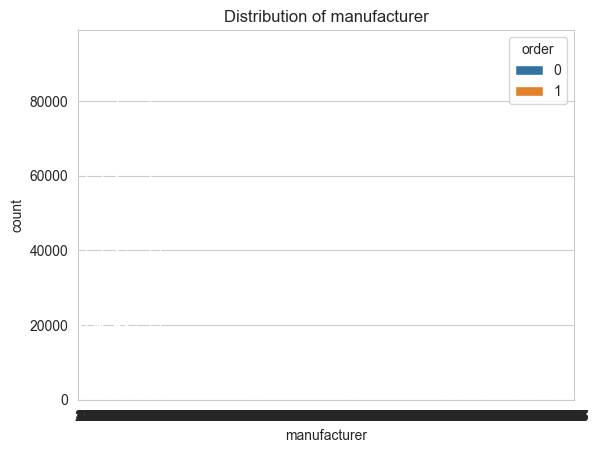

In [ ]:
plot = sns.countplot(x="manufacturer", hue="order", data=df)

plt.title("Distribution of Manufacturer")
plt.show()

## Group

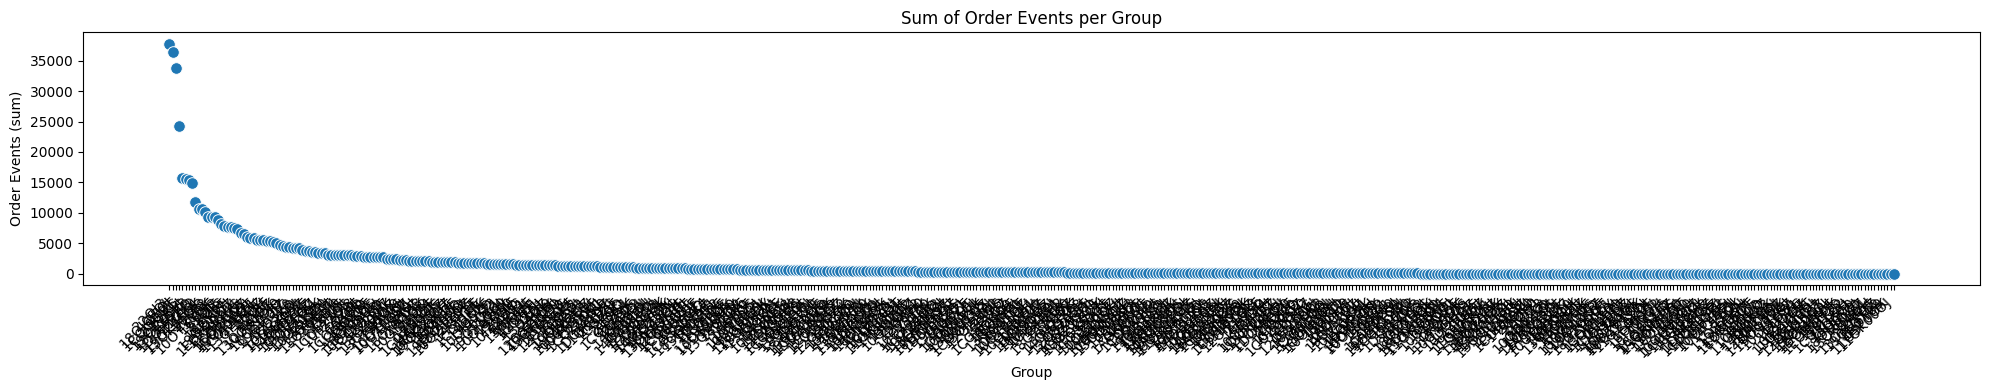

In [ ]:
plot = sns.countplot(x="group", hue="order", data=df)

plt.title("Distribution of Group")
plt.show()

## Content

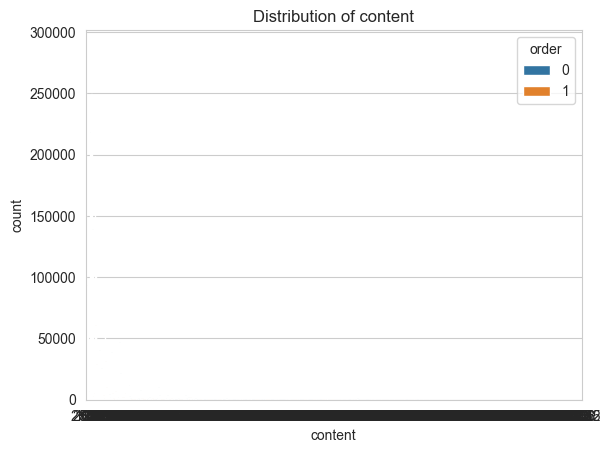

In [107]:
plot = sns.countplot(x="content", hue="order", data=df)
plot.get_yaxis().get_major_formatter().set_scientific(False)

plt.title("Distribution of content")
plt.show()

## Unit

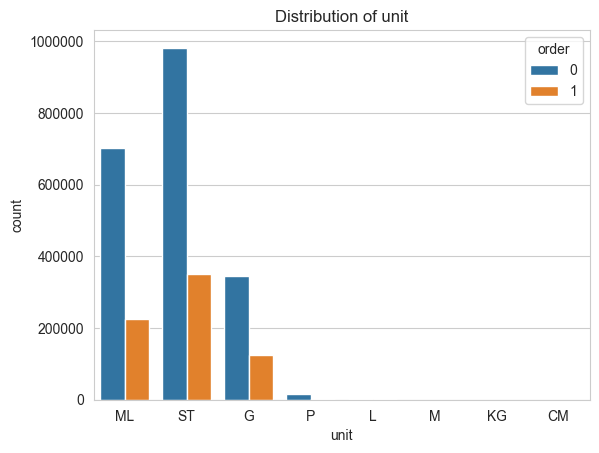

In [106]:
plot = sns.countplot(x="unit", hue="order", data=df)
plot.get_yaxis().get_major_formatter().set_scientific(False)

plt.title("Distribution of unit")
plt.show()

## Pharm Form

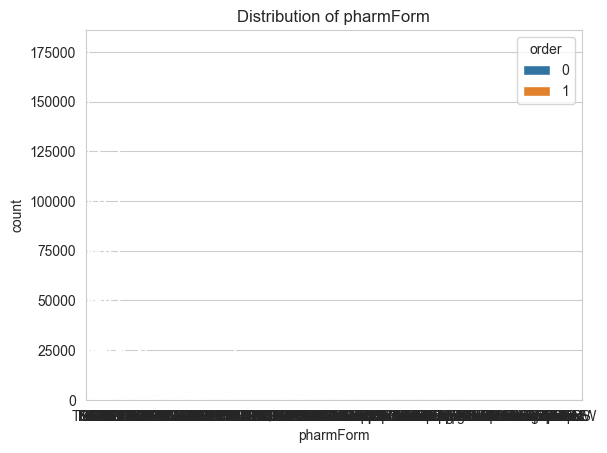

In [105]:
plot = sns.countplot(x="pharmForm", hue="order", data=df)

plt.title("Distribution of pharmForm")
plt.show()

## Generic Product

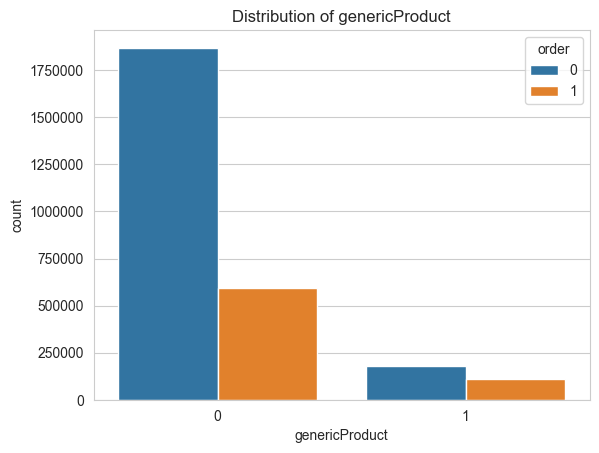

In [103]:
plot = sns.countplot(x="genericProduct", hue="order", data=df)
plot.get_yaxis().get_major_formatter().set_scientific(False)

plt.title("Distribution of genericProduct")
plt.show()

## Sales Index

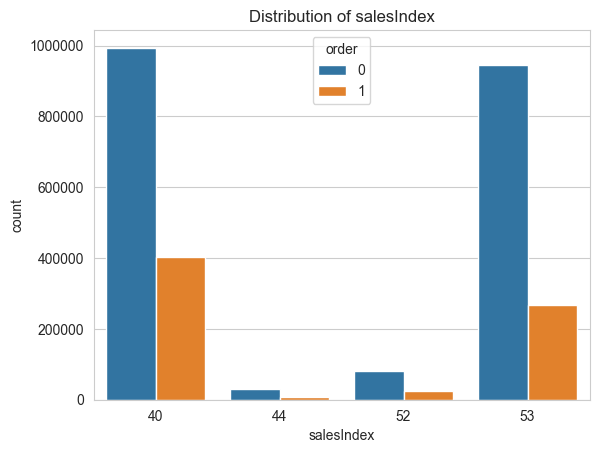

In [102]:
plot = sns.countplot(x="salesIndex", hue="order", data=df)
plot.get_yaxis().get_major_formatter().set_scientific(False)

plt.title("Distribution of salesIndex")
plt.show()

## Category

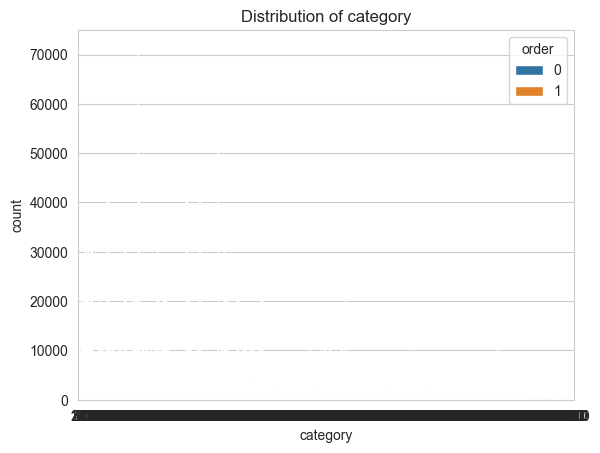

In [ ]:
plot = sns.countplot(x="category", hue="order", data=df)

plt.title("Distribution of category")
plt.show()

## Campaign Index

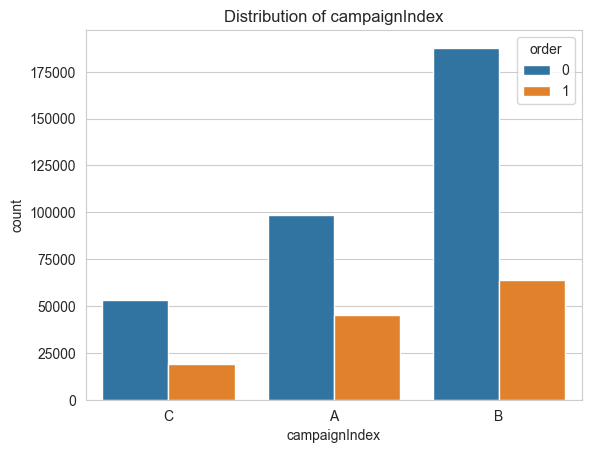

In [98]:
plot = sns.countplot(x="campaignIndex", hue="order", data=df)

plt.title("Distribution of campaignIndex")
plt.show()

## Reference Price

In [ ]:
plot = sns.countplot(x="rrp", hue="order", data=df)
plot.get_yaxis().get_major_formatter().set_scientific(False)

plt.title("Distribution of rrp")
plt.show()